In [1]:
import libs.append_path
from add_python_libraries import *
import pd_filter_fcns

import scipy as sp
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt
import numpy as np
import numpy_rms
import cmath

from cyntec import Inductor_pdis

from current_buck_waveforms import Current_buck_waveforms
from current_carova_MR_waveforms import Current_carova_MR_waveforms

from current_buck_fft import Current_buck_FFT

from capacitorZ_multibank import Zcapbanks
from current_capbanks_fft import Current_capbanks_FFT
from current_capbanks_waveforms import Current_capbanks_waveforms

In [20]:
input_params = {'vin' : 20,
                'vout': 12,
                'pin' : 100, 
                'eff' : 0.97, 
                'fs'  :175e3,
                'ton_mult':1,
                'tambient':25,
                'lout':{'family'   :'hbed053t',
                        'value(uH)':1.0,
                        'config'   :'single'},
                'lvl_config':'3 level carova',
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']

Csp   = {'label':'sp1','type':'sp',  'C':10e-6,  'ESR':100e-3, 'ESL':2e-9,   'n':1, 'series':0}
Cmlcc1 = {'label':'mlcc1','type':'mlcc','C':0.9e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':4, 'series':0}
Cmlcc2 = {'label':'mlcc2','type':'mlcc','C':0.52e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':4, 'series':0}
Cmlcc3 = {'label':'mlcc3','type':'mlcc','C':0.052e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':1, 'series':0}
Caplist = [Csp,Cmlcc1,Cmlcc2,Cmlcc3]

In [21]:
pd.DataFrame(Caplist)

,label,type,C,ESR,ESL,n,series
0,sp1,sp,1.000000e-05,0.100,2.000000e-09,1,0
1,mlcc1,mlcc,9.000000e-07,0.005,5.000000e-10,4,0
2,mlcc2,mlcc,5.200000e-07,0.005,5.000000e-10,4,0
3,mlcc3,mlcc,5.200000e-08,0.005,5.000000e-10,1,0


In [22]:
lobj = Inductor_pdis(input_params)
iobj = {True:Current_carova_MR_waveforms,
        False:Current_buck_waveforms}[lobj.ckt['state count']==6](lobj)

time_datapoints = iobj.time_datapoints
I_inductor = iobj.i_ind
I_zin_ac = iobj.i_zin_ac

([<matplotlib.lines.Line2D at 0x114d0d1d0>],
 [<matplotlib.lines.Line2D at 0x114d0d310>])

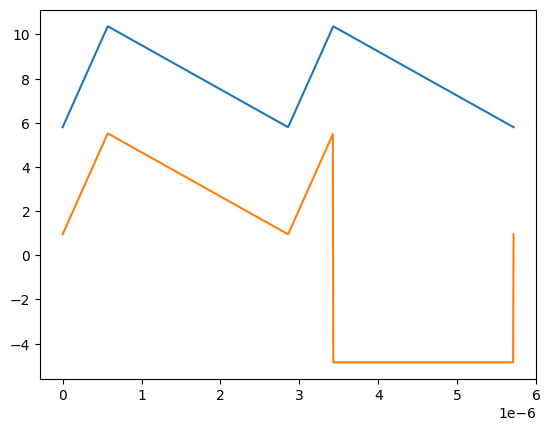

In [23]:
plt.plot(time_datapoints,I_inductor),plt.plot(time_datapoints,I_zin_ac)

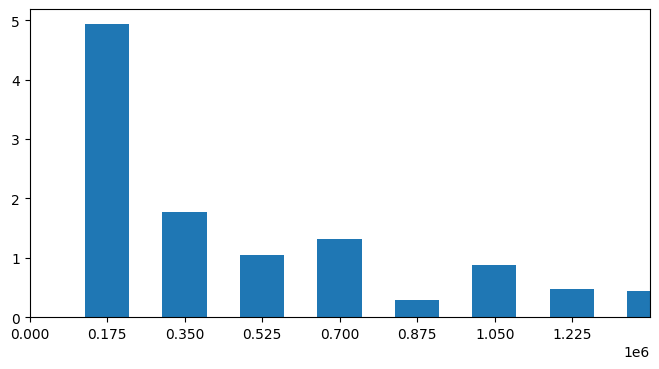

In [24]:
currents_buckfftobj = Current_buck_FFT(iobj)
currents_buckfftobj.plot_i_zin_fft()

In [25]:
zcapbanks = Zcapbanks(Caplist)


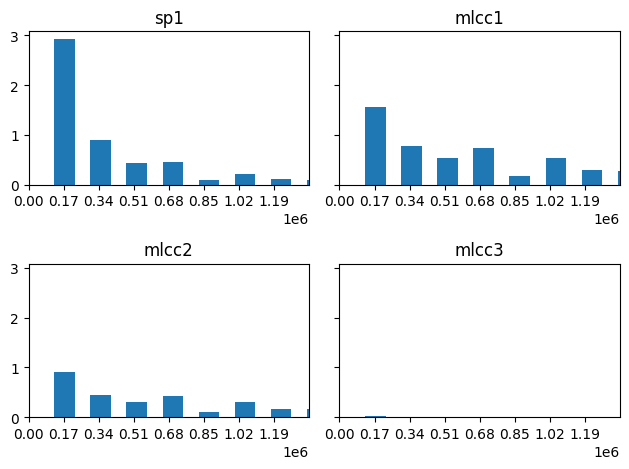

In [27]:

currents_capsfftobj = Current_capbanks_FFT(currents_buckfftobj,zcapbanks)
currents_capsfftobj.plot_i_allbanks_fft()

([<matplotlib.lines.Line2D at 0x115db5a90>],
 [<matplotlib.lines.Line2D at 0x115db5f90>])

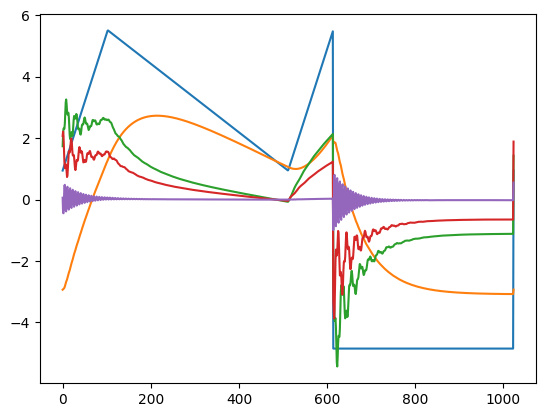

In [28]:
i_zbank_ac_obj = Current_capbanks_waveforms(currents_capsfftobj)
plt.plot(i_zbank_ac_obj.i_total_ac),plt.plot(i_zbank_ac_obj.i_nbanks_ac[0]),\
plt.plot(i_zbank_ac_obj.i_nbanks_ac[1]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[2]),\
plt.plot(i_zbank_ac_obj.i_nbanks_ac[3])

In [29]:
i_zbank_ac_obj.i_capsfftobj.i_nbank_fft

[{'label': 'sp1',
  'type': 'sp',
  'C': 1e-05,
  'ESR': 0.1,
  'ESL': 2e-09,
  'n': 1,
  'series': 0,
  'fftdata': array([-9.59765645e-14+2.18890052e-19j, -7.95138542e+02-1.27451280e+03j,
         -1.32289610e+02-4.39749795e+02j, ...,
         -1.89256199e+02-1.21212752e+02j, -1.32289610e+02+4.39749795e+02j,
         -7.95138542e+02+1.27451280e+03j], shape=(1024,))},
 {'label': 'mlcc1',
  'type': 'mlcc',
  'C': 9e-07,
  'ESR': 0.005,
  'ESL': 5e-10,
  'n': 4,
  'series': 0,
  'fftdata': array([-3.45515632e-14-1.37316533e-19j,  2.21014522e+02-7.63699652e+02j,
          3.02949377e+02-2.51197351e+02j, ...,
         -2.00910536e+02+1.88308555e+02j,  3.02949377e+02+2.51197351e+02j,
          2.21014522e+02+7.63699652e+02j], shape=(1024,))},
 {'label': 'mlcc2',
  'type': 'mlcc',
  'C': 5.2e-07,
  'ESR': 0.005,
  'ESL': 5e-10,
  'n': 4,
  'series': 0,
  'fftdata': array([-1.99631254e-14-7.95767622e-20j,  1.28590265e+02-4.40883441e+02j,
          1.75488221e+02-1.44273993e+02j, ...,
        

In [ ]:
numpy_rms.rms(i_zbank_ac_obj.i_total_ac),numpy_rms.rms(i_zbank_ac_obj.i_nbanks_ac[0])

In [ ]:
i_zbank_ac_obj.i_total_ac